# This is to deal only with the ID = 0 File for finding NSC

In [13]:
import numpy as np
import pandas, os, astropy, scipy, math
import matplotlib.pyplot as plt
import sklearn
from photutils.aperture import CircularAperture, SkyCircularAperture, aperture_photometry, EllipticalAperture, SkyEllipticalAperture
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.wcs.utils import pixel_to_skycoord
import astropy.io.fits as fits
from reproject import reproject_interp
import img_scale
from mpl_toolkits.axes_grid1 import Divider, Size
from astropy.cosmology import FlatLambdaCDM 
from astropy.wcs.utils import proj_plane_pixel_scales

In [14]:
# Writing a function to calculate the magnitude difference bewteen the 2 largest objects
def max_mag_diff(magar):
    lstmag = magar.tolist()
    sortedlstmag = sorted(lstmag)
    magdif1 = sortedlstmag[0] - sortedlstmag[1]
    print(" The magnitude difference between the brightest and 2nd brightest object is {}".format(magdif1))

In [15]:
galcen = pandas.read_csv('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/77_SMDG1214055+070631_gal_loc.csv')
galcenx77 = galcen['xc'].values[0]
galceny77 = galcen['yc'].values[0]
cut_cat77 = pandas.read_csv('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/77_SMDG1214055+070631_cut_catalog.csv')
cut_cat77.columns

Index(['Unnamed: 0', 'ext', 'chip', 'xc', 'yc', 'chi', 'snr', 'sharpness',
       'roundness', 'pa', 'crowding', 'objtype', 'F475W_count', 'F475W_sky',
       'F475W_count_rate', 'F475W_count_rate_uncer', 'F475W_mag_vega',
       'F475W_mag_ubvri', 'F475W_mag_uncer', 'F475W_chi', 'F475W_snr',
       'F475W_sharpness', 'F475W_roundness', 'F475W_crowding', 'F475W_flag',
       'F814W_count', 'F814W_sky', 'F814W_count_rate',
       'F814W_count_rate_uncer', 'F814W_mag_vega', 'F814W_mag_ubvri',
       'F814W_mag_uncer', 'F814W_chi', 'F814W_snr', 'F814W_sharpness',
       'F814W_roundness', 'F814W_crowding', 'F814W_flag', 'aper_4', 'aper_8',
       'newconcent'],
      dtype='object')

In [16]:
# Define cuts that we are using(comment out this cell to get the original data)
use_cat = cut_cat77

max_mag = 35.  # Maxmum mag (Telescope cut)
snr_thresh = 3.  # For nearby, 5
# crowd_thresh = 0.5 #[mag], Normal cut  
# sharp_thresh = 0.25 #Normal cut  defraction spikes
# round_thresh = 3.  #Weak constraint (elongated)
flag_thresh = np.array([0, 2])
flag_label = np.array(['Good', 'Edge', 'Bad,Sat-pixel', 'Edge+badpixel'])

## Instrumental VEGAMAG magnitude cut
print(f"Total dolphot catalogue length: {len(use_cat)}")
print(f"Require: mag < {max_mag}")
condition = (use_cat.iloc[:,16] < max_mag) & (use_cat.iloc[:,29] < max_mag)
sub_dolcut_cat = use_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## SNR cut
print(f"Require: S/N > {snr_thresh}.")
condition = (sub_dolcut_cat.iloc[:,20] > snr_thresh) & (sub_dolcut_cat.iloc[:,33] > snr_thresh)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## Object Type cut
print("Remove sources that are not type point-like.")
condition = (sub_dolcut_cat.iloc[:,11] <= 2)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## Photometry quality flag cut
print("Remove sources that have flag= ", flag_thresh, "or", flag_label[flag_thresh])
condition = np.isin(sub_dolcut_cat.iloc[:,24], flag_thresh) & np.isin(sub_dolcut_cat.iloc[:,37], flag_thresh)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

cut_cat77 = sub_dolcut_cat 

Total dolphot catalogue length: 93545
Require: mag < 35.0
New catalogue length: 93291
Require: S/N > 3.0.
New catalogue length: 5113
Remove sources that are not type point-like.
New catalogue length: 4274
Remove sources that have flag=  [0 2] or ['Good' 'Bad,Sat-pixel']
New catalogue length: 4237


In [17]:
#creating 2 numpy arrays that hold the xc and yc of each bright object
xcgal77 = cut_cat77['xc'].to_numpy()
ycgal77 = cut_cat77['yc'].to_numpy()
f475mag77 = cut_cat77['F475W_mag_vega'].to_numpy()
f814mag77 = cut_cat77['F814W_mag_vega'].to_numpy()

In [18]:
#calculating the distance from the centre of the galaxy for each bright object
distgal77 = np.sqrt((xcgal77 - galcenx77)**2 + (ycgal77 - galceny77)**2)


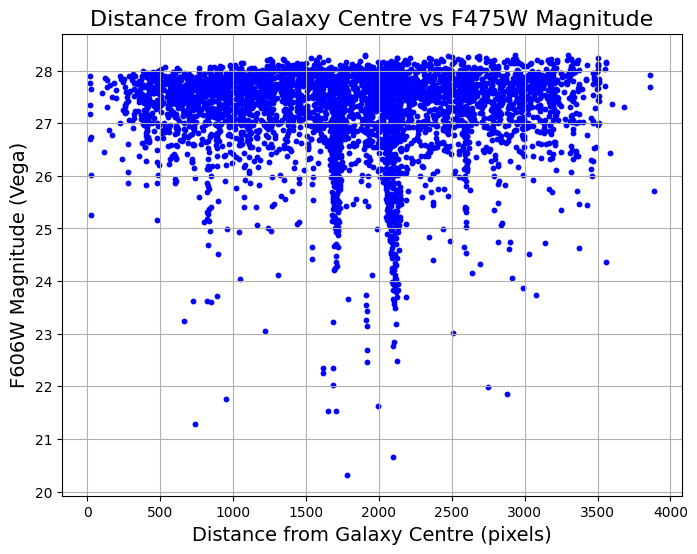

In [19]:
#plotting distance vs magnitude for F606W filter
plt.figure(figsize=(8,6))
plt.scatter(distgal77, f475mag77, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F475W Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F606W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

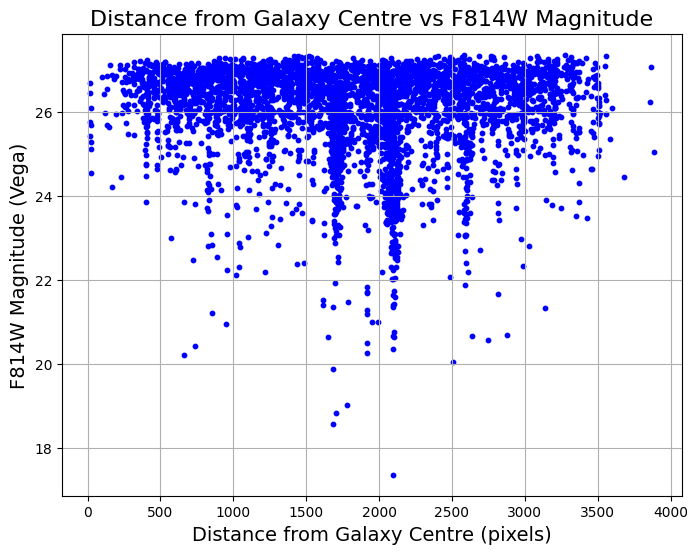

In [20]:
#plotting the distance vs magnitude for F814W filter
plt.figure(figsize=(8,6))
plt.scatter(distgal77, f814mag77, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F814W Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

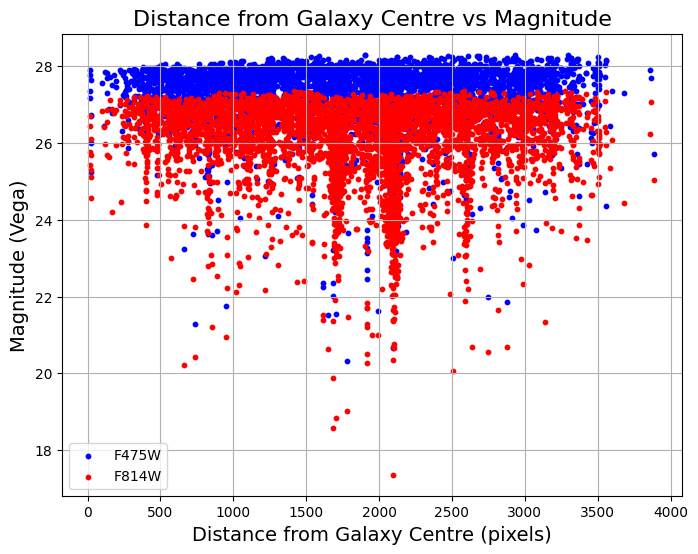

In [21]:
#plotting distance vs magnitude for both filters together
plt.figure(figsize=(8,6))
plt.scatter(distgal77, f475mag77, color='blue', s=10, label='F475W')
plt.scatter(distgal77, f814mag77, color='red', s=10, label='F814W')
plt.title('Distance from Galaxy Centre vs Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('Magnitude (Vega)', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [25]:
#converting re(arcsec) to pixels
re_arcsec77 = 9.29

hdul77 = fits.open('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/ID_77_F475/MAST_2025-11-11T04_46_43.017Z/HST/jc8a05020_drc.fits')
if len(hdul77) > 1:
    hdr77 = hdul77[1].header
else:
    hdr77 = hdul77[0].header
wcs77 = WCS(hdr77)
pixel_scale_degrees77 = proj_plane_pixel_scales(wcs77)
scale_arcsec_per_pixel77 = pixel_scale_degrees77[0] * 3600
scale_pixel_per_arcsec77 = 1 / scale_arcsec_per_pixel77
re_pixels77 = re_arcsec77 * scale_pixel_per_arcsec77
print(re_pixels77)

185.80000000000965


In [26]:
#refining the bright object list to only include objects within re and finding the colour of the objects
distgal_re77 = distgal77[distgal77 <= re_pixels77]
f475mag_re77 = f475mag77[distgal77 <= re_pixels77]
f814mag_re77 = f814mag77[distgal77 <= re_pixels77]
color77 = f475mag_re77 - f814mag_re77

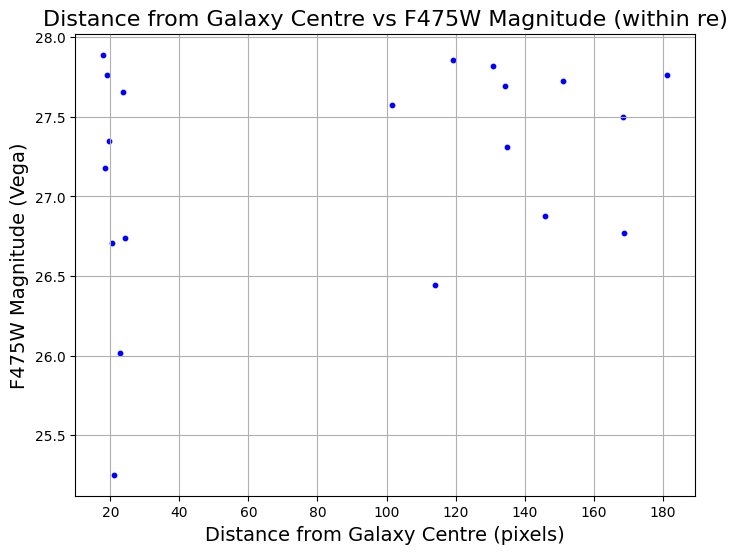

In [27]:
#plotting distance vs magnitude for f475w in re 
plt.figure(figsize=(8,6))
plt.scatter(distgal_re77, f475mag_re77, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F475W Magnitude (within re)', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F475W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()  

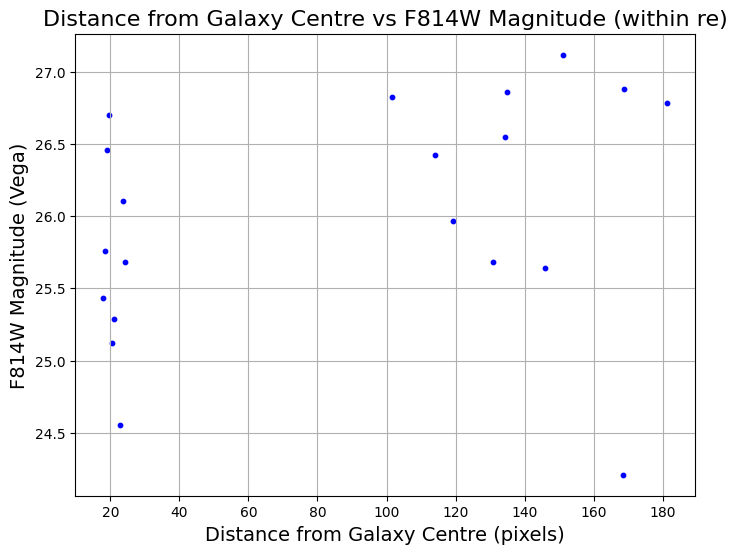

In [28]:
#plotting distance vs magnitude for f814w in re
plt.figure(figsize=(8,6))
plt.scatter(distgal_re77, f814mag_re77, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F814W Magnitude (within re)', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14) 
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

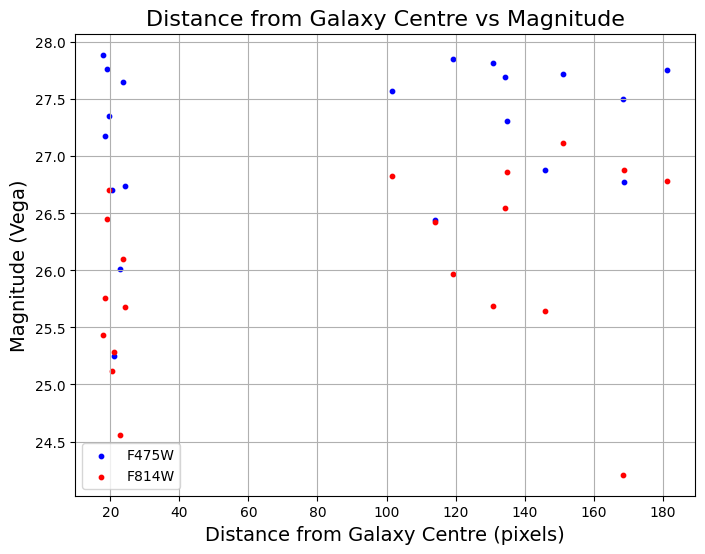

In [29]:
#plotting distance vs magnitude for the objects within re for both filters together
plt.figure(figsize=(8,6))
plt.scatter(distgal_re77, f475mag_re77, color='blue', s=10, label='F475W')
plt.scatter(distgal_re77, f814mag_re77, color='red', s=10, label='F814W')
plt.title('Distance from Galaxy Centre vs Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('Magnitude (Vega)', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [30]:
# normalising the distance in terms of re
distgal_re77_n = distgal_re77/re_pixels77

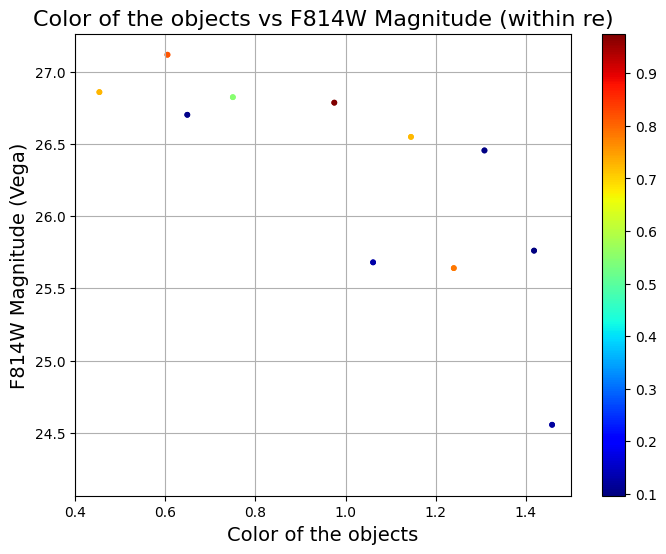

In [84]:
#plotting a color vs magnitude for the objects within a re
plt.figure(figsize=(8,6))

plt.scatter(color77, f814mag_re77, c = distgal_re77_n,cmap = 'jet', s=10)
plt.title('Color of the objects vs F814W Magnitude (within re)', fontsize=16)
plt.xlabel('Color of the objects', fontsize=14) 
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.xlim(0.4, 1.5)
plt.grid()
plt.colorbar()
plt.scatter(color77, f814mag_re77, c = distgal_re77_n,cmap = 'jet', s=10)
plt.show()

In [34]:
#Converting into absolute Mag
distgalpc0 = 29.6 * 1e6
absmag_re0 = f814mag_re77 - 5*np.log10(distgalpc0/10)

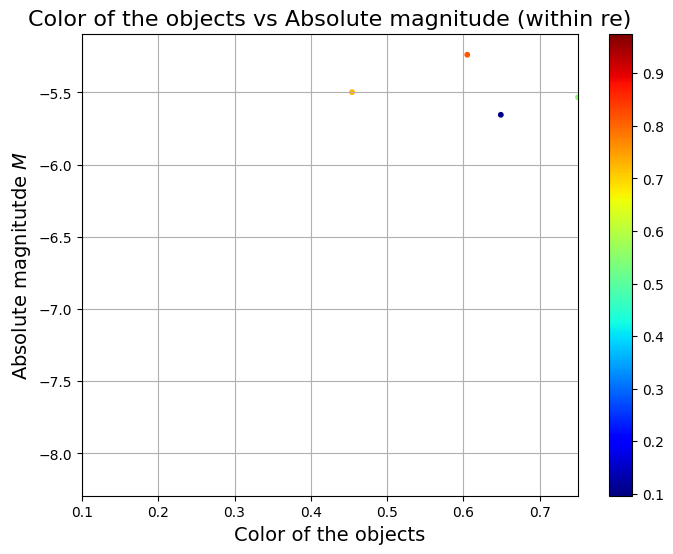

In [35]:
#plotting a color vs absolute magnitude for the objects within a re
plt.figure(figsize=(8,6))
plt.scatter(color77, absmag_re0, c = distgal_re77_n,cmap = 'jet', s=10)
plt.title('Color of the objects vs Absolute magnitude (within re)', fontsize=16)
plt.xlabel('Color of the objects', fontsize=14) 
plt.ylabel('Absolute magnitutde $M$', fontsize=14)
plt.xlim(0.1, 0.75)
plt.grid()
plt.colorbar()
plt.show()

In [36]:
#finding the mag of the object in 0.2 re
repixelsp277 = re_pixels77 * 0.2
print(repixelsp277)
f814mag_rep277 = f814mag77[distgal77 <= repixelsp277]

37.16000000000193


In [37]:
#Finding the mag difference of objects in 1 re then 0.2 re
max_mag_diff(f475mag_re77)# 1 re
max_mag_diff(f814mag_rep277)# 0.2 re

 The magnitude difference between the brightest and 2nd brightest object is -0.7620000000000005
 The magnitude difference between the brightest and 2nd brightest object is -0.5670000000000002


In [40]:
# adding concentration index to the catalog
newconcent77 = cut_cat77['newconcent']

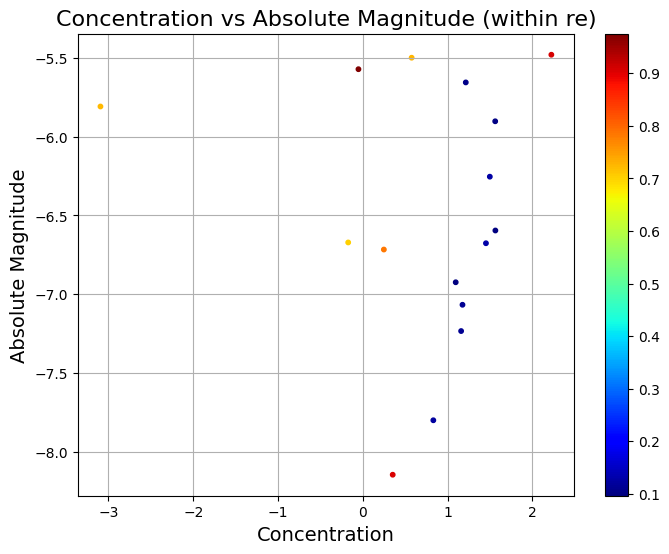

In [41]:
#Plotting the concentration vs Absolute magnitude graph withing 1 re
plt.figure(figsize=(8,6))
plt.scatter(newconcent77[distgal77 <= re_pixels77], absmag_re0, c = distgal_re77_n,cmap = 'jet', s=10)
plt.title('Concentration vs Absolute Magnitude (within re)', fontsize=16)
plt.xlabel('Concentration', fontsize=14) 
plt.ylabel('Absolute Magnitude', fontsize=14)
plt.grid()
plt.colorbar()
plt.show()

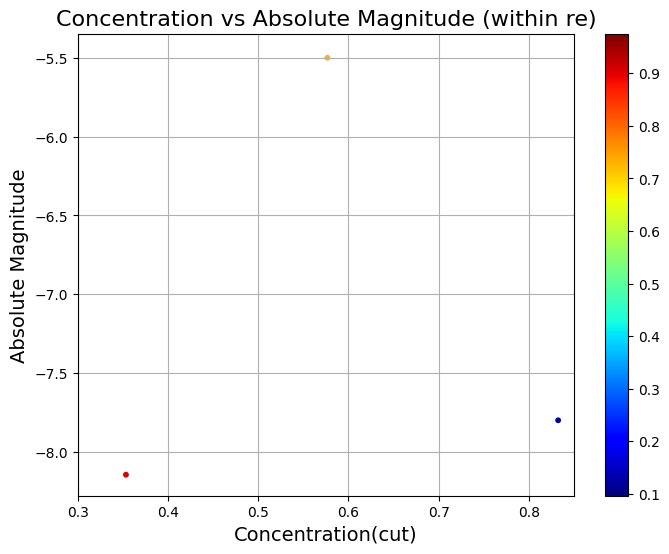

In [44]:
#Plotting the concentration(cut) vs Absolute magnitude graph withing 1 re
plt.figure(figsize=(8,6))
plt.scatter(newconcent77[distgal77 <= re_pixels77], absmag_re0, c = distgal_re77_n,cmap = 'jet', s=10)
plt.title('Concentration vs Absolute Magnitude (within re)', fontsize=16)
plt.xlabel('Concentration(cut)', fontsize=14) 
plt.ylabel('Absolute Magnitude', fontsize=14)
plt.xlim(0.3, 0.85)
plt.grid()
plt.colorbar()
plt.show()

In [45]:
# accessing the fits file to get the header and the wcs information
F814W0 = hdul77[1].data
F814W0header = hdul77[1].header



In [86]:
# Writing code to find the index of the brightest object in 1 re 
minmag0 = 50
for i in range(len(f814mag_re77)):
    if f814mag_re77[i] < minmag0 and 0.4 < color77[i] < 1.5:
        minmag0 = f814mag_re77[i]
        objdist0 = distgal_re77[i]

index0 = 0
for i in range(len(f814mag77)):
    if f814mag77[i] == minmag0:
        index0 = i

print(index0)
print(minmag0)
print(f814mag_re77)
print(distgal_re77)
print(color77)

objxc0 = xcgal77[index0]
objyc0 = ycgal77[index0]
print(objxc0, objyc0, distgal77[index0])

486
24.555
[24.209 25.289 24.555 25.122 25.432 26.424 25.68  25.64  25.685 26.878
 26.824 25.761 25.968 26.103 26.786 26.455 27.118 26.859 26.702 26.549]
[168.44243805  20.96192437  22.66006897  20.5824062   17.93082864
 114.12003115  24.11742747 145.81538942 130.76603533 168.90785813
 101.55821523  18.45183818 119.29333637  23.61394    181.20472736
  18.93918352 151.25604064 135.00887029  19.59154551 134.22101004]
[ 3.293 -0.038  1.458  1.585  2.459  0.02   1.061  1.24   2.134 -0.107
  0.75   1.418  1.889  1.551  0.975  1.308  0.605  0.454  0.649  1.145]
3260.49 1596.31 22.6600689695907


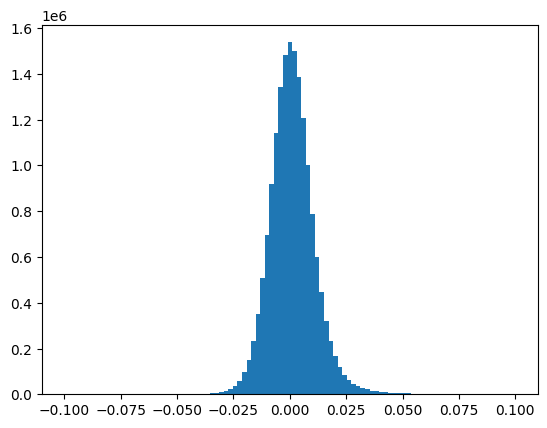

In [87]:
# Checking the distribution of pixel values in the F814W image
plt.hist(F814W0.ravel(),np.linspace(-0.1,0.1, 100))
plt.show()

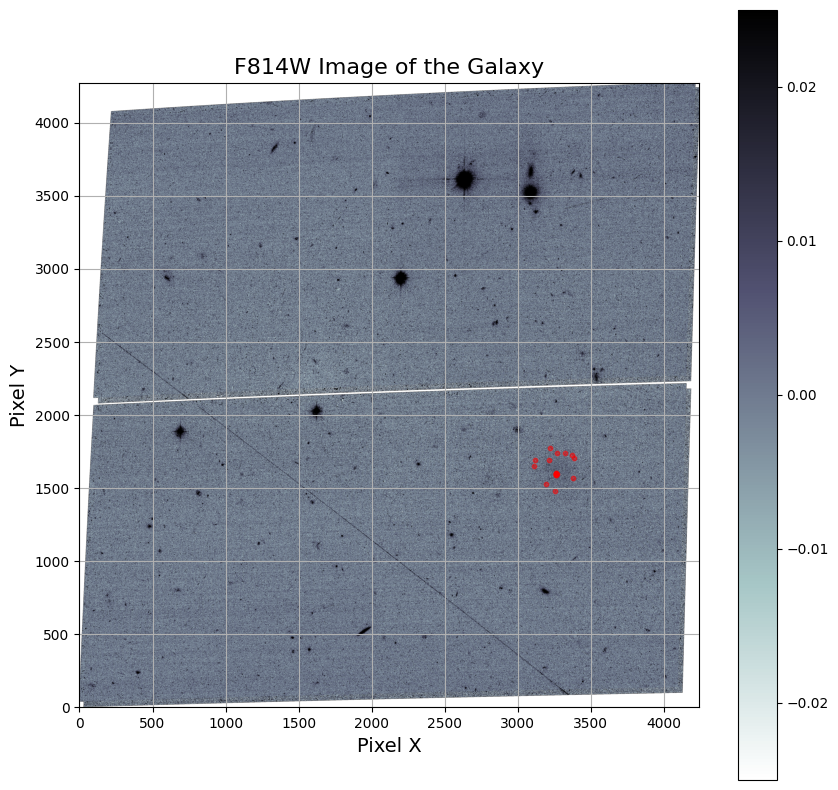

In [88]:
#Plotting the F814W image for the galaxy and overplot all the bright objects within re

fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal77[distgal77 <= re_pixels77], ycgal77[distgal77 <= re_pixels77], color='red', s=10, alpha = 0.5, label='Bright objects within re')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('Pixel X', fontsize=14)
plt.ylabel('Pixel Y', fontsize=14)
plt.grid()
plt.show()



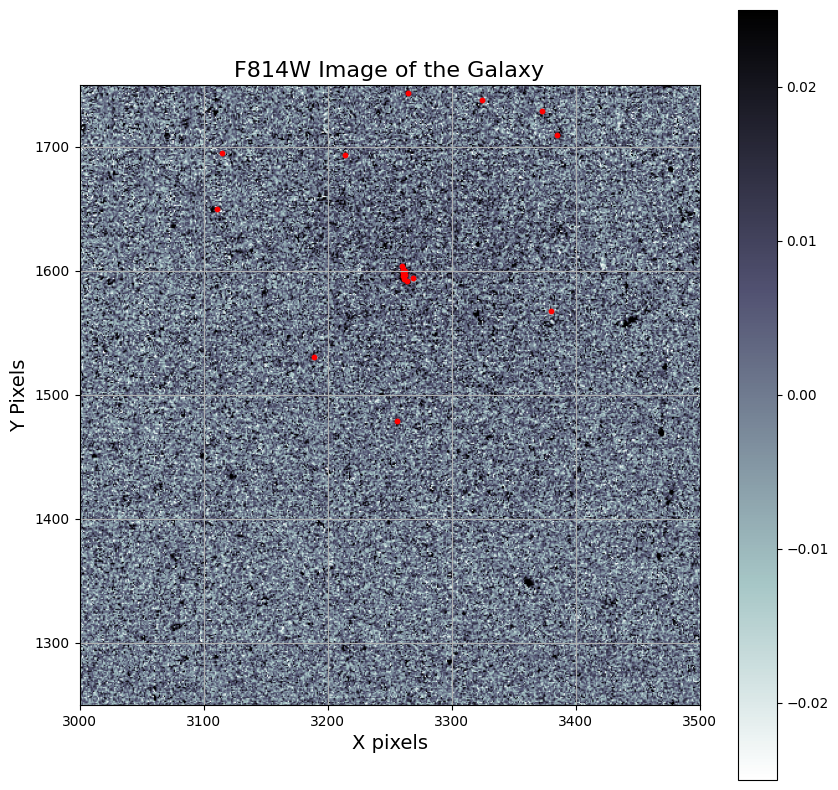

In [89]:
# zooming in for better visualization of the bright objects within re
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal77[distgal77 <= re_pixels77], ycgal77[distgal77 <= re_pixels77], color='red', s=10, label='Bright objects within re')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixels', fontsize=14)
plt.ylabel('Y Pixels', fontsize=14)
plt.xlim(3000, 3500)
plt.ylim(1250, 1750)
plt.grid()
plt.show()

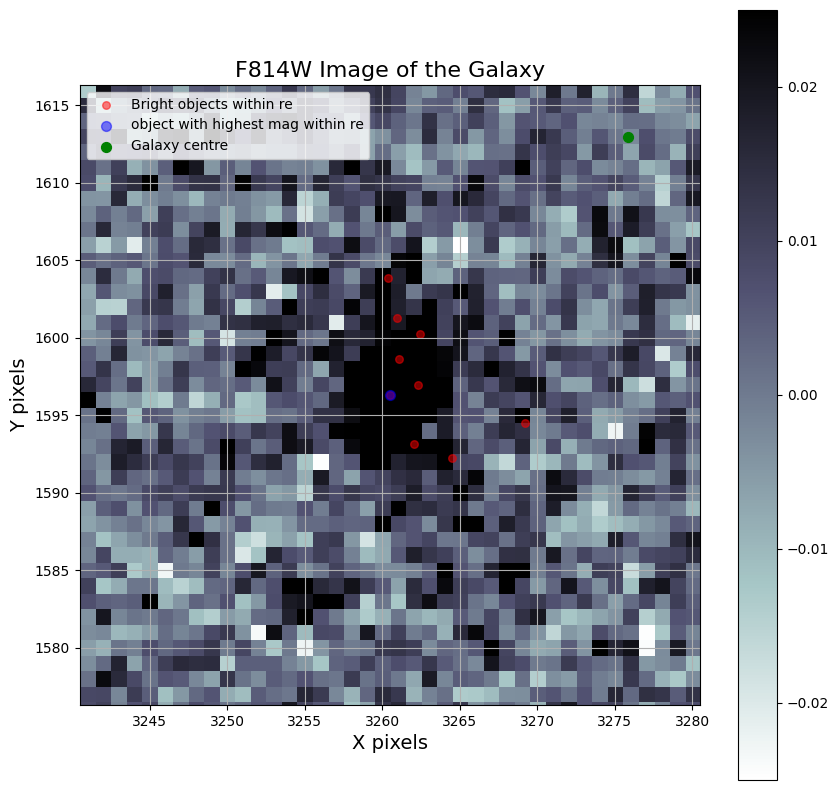

In [90]:
# zooming in even more to see the brightest and closest object to the centre of the galaxy
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal77[distgal77 <= re_pixels77], ycgal77[distgal77 <= re_pixels77], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc0, objyc0, color='blue', s=50, alpha = 0.5, label='object with highest mag within re')
plt.scatter(galcenx77, galceny77, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixels', fontsize=14)
plt.ylabel('Y pixels', fontsize=14)
plt.xlim(objxc0-20, objxc0+20)
plt.ylim(objyc0-20, objyc0+20)
plt.legend()
plt.grid()
plt.show()

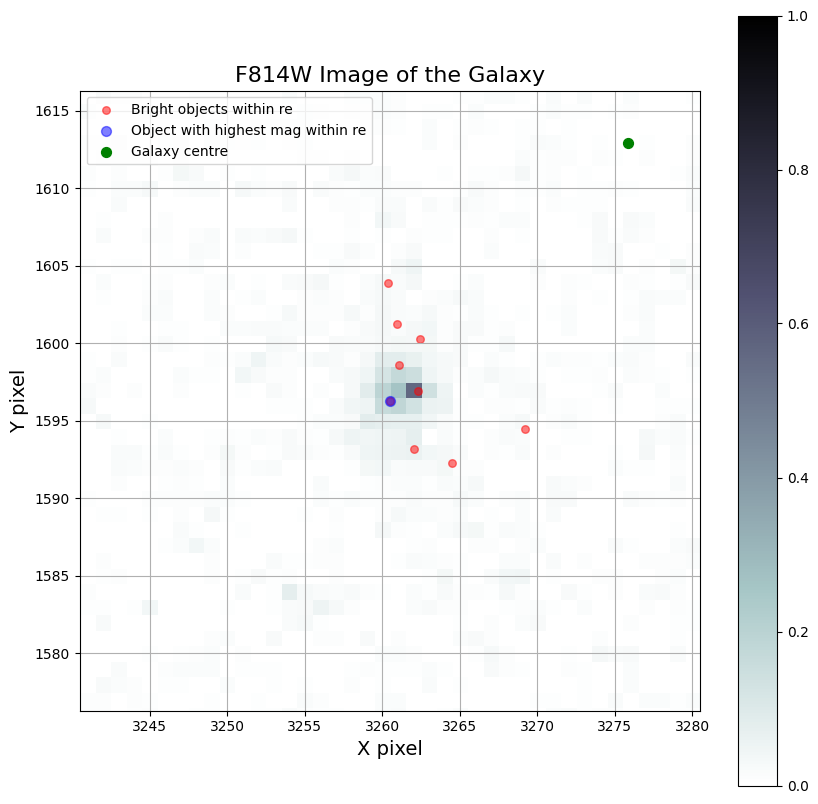

In [91]:
# trying to see how bright it is
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = 0, vmax = 1)
plt.colorbar()
plt.scatter(xcgal77[distgal77 <= re_pixels77], ycgal77[distgal77 <= re_pixels77], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc0, objyc0, color='blue', s=50, alpha = 0.5, label='Object with highest mag within re')
plt.scatter(galcenx77, galceny77, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc0-20, objxc0+20)
plt.ylim(objyc0-20, objyc0+20)
plt.legend()
plt.grid()
plt.show()

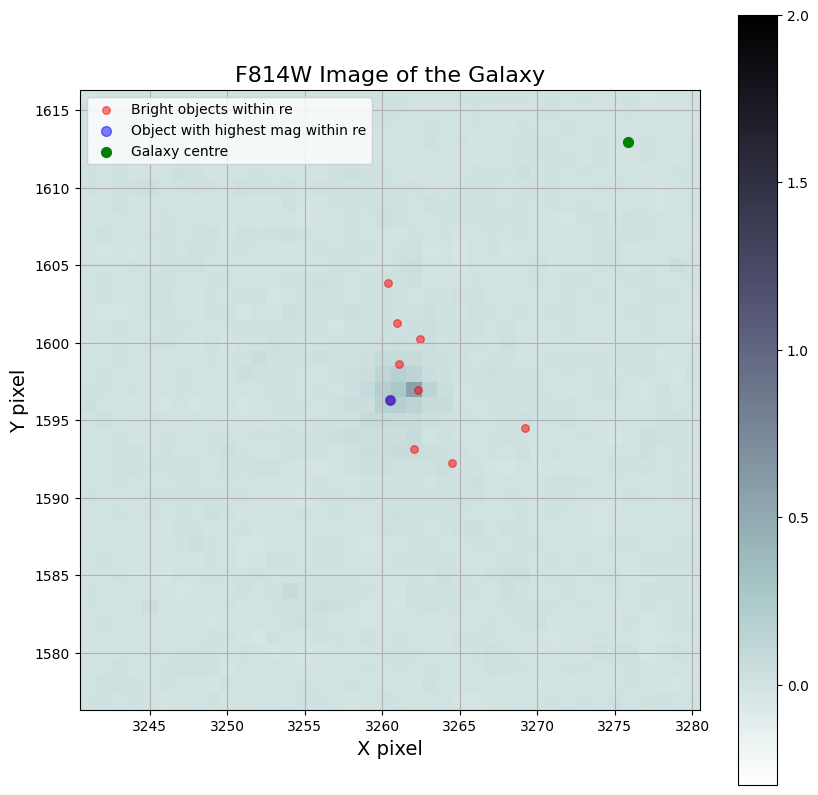

In [92]:
# trying to see how bright it is
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.3, vmax = 2)
plt.colorbar()
plt.scatter(xcgal77[distgal77 <= re_pixels77], ycgal77[distgal77 <= re_pixels77], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc0, objyc0, color='blue', s=50, alpha = 0.5, label='Object with highest mag within re')
plt.scatter(galcenx77, galceny77, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc0-20, objxc0+20)
plt.ylim(objyc0-20, objyc0+20)
plt.legend()
plt.grid()
plt.show()

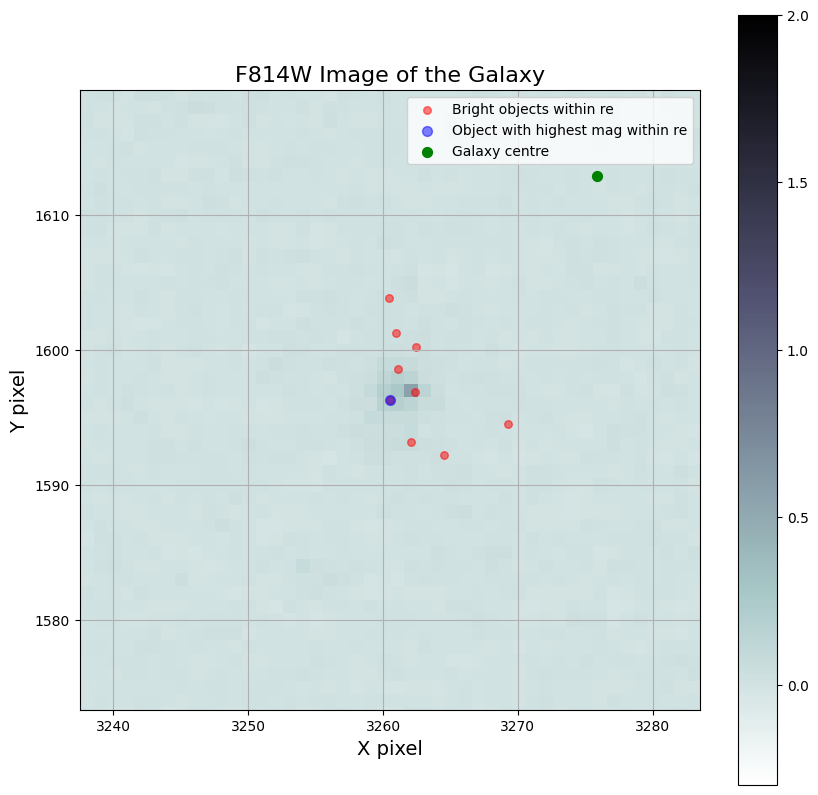

In [93]:
# Zooming in even more
lim = round(objdist0)
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.3, vmax = 2)
plt.colorbar()
plt.scatter(xcgal77[distgal77 <= re_pixels77], ycgal77[distgal77 <= re_pixels77], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc0, objyc0, color='blue', s=50, alpha = 0.5, label='Object with highest mag within re')
plt.scatter(galcenx77, galceny77, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc0-lim, objxc0+lim)
plt.ylim(objyc0-lim, objyc0+lim)
plt.legend()
plt.grid()
plt.show()

# Conclusion
Not too sure if the object picked is an NSC, it seems like there is another brighter object which didnt make it through the color cut
